## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler


## DEFINITION OF VARIABLES

In [2]:
SOURCE_FILE = 'all_spectra.csv'
NORMAL_POLYMER = 'Polyethylene'

## Affine Coupling Layer

In [3]:
class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim = 64):
        super().__init__()
        self.dim = dim
        self.split_dim = dim // 2

        self.scale_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim,hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim)),
            nn.Tanh()
        )

        self.shift_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim,hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim))
        )

    def forward(self, x):
        x1,x2 = x[:,:self.split_dim], x[:,self.split_dim:]

        s = self.scale_net(x1)
        s = s * 0.5
        t = self.shift_net(x1)

        y1 = x1
        y2 = x2 * torch.exp(s) + t

        log_det = s.sum(dim = 1)

        return torch.cat([y1, y2], dim=1), log_det
    
    def inverse(self, y):
        y1, y2 = y[:, :self.split_dim], y[:, self.split_dim:]

        s = self.scale_net(y1)
        s = s * 0.5
        t = self.shift_net(y1)

        x1 = y1
        x2 = (y2 - t) * torch.exp(-s)

        return torch.cat([x1, x2], dim=1)

In [4]:
class StandardGaussian:
    def __init__(self, dim):
        self.dim = dim
        self.distribution = torch.distributions.MultivariateNormal(
            torch.zeros(dim),
            torch.eye(dim)
        )

    def log_prob(self, z):
        return self.distribution.log_prob(z)
    
    def sample(self, n_samples):
        return self.distribution.sample((n_samples,))


In [5]:
class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.register_buffer('permutation', torch.randperm(dim))
        self.register_buffer('inverse_permutation', torch.argsort(self.permutation))

    def forward(self, x):
        return x[:, self.permutation], torch.zeros(x.shape[0], device=x.device)
    
    def inverse(self, y):
        return y[:,self.inverse_permutation]
    

In [6]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim, n_layers = 4, hidden_dim = 64):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.base_dist = StandardGaussian(dim)
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(AffineCouplingLayer(dim, hidden_dim))
            if i < n_layers - 1:
                self.layers.append(PermutationLayer(dim))

    def forward(self, x):

        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        log_prob_z = self.base_dist.log_prob(z)
        log_prob_x = log_prob_z + log_det_sum

        return log_prob_x
    
    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x
    
    def sample(self, n_samples):
        z = self.base_dist.sample(n_samples)
        x = self.inverse(z)
        return x


In [7]:
def train_flow(model, data, n_epochs = 100, batch_size = 32, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    n_batches = len(data) // batch_size
    losses = []

    for epoch in tqdm(range(n_epochs)):
        perm = torch.randperm(len(data))
        data_shuffled = data[perm]

        epoch_loss = 0

        for i in range(n_batches):
            batch = data_shuffled[i*batch_size:(i+1)*batch_size]
            
            optimizer.zero_grad()

            log_prob = model(batch)
            loss = -log_prob.mean()

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}')

    return losses

## Training

In [8]:
df = pd.read_csv(SOURCE_FILE, index_col=False)
normal_data = df[df['polymer'] == NORMAL_POLYMER].drop('polymer', axis=1).values

scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)
train_tensor = torch.FloatTensor(normal_scaled)

n_features = train_tensor.shape[1]
model = NormalizingFlow(dim = n_features, n_layers = 6, hidden_dim = 256)

losses = train_flow(model, train_tensor, n_epochs = 100, batch_size = 32, lr = 1e-4)

model.eval()
with torch.no_grad():
    for polymer in df['polymer'].unique():
        polymer_data = df[df['polymer'] == polymer].drop('polymer', axis=1).values
        polymer_scaled = scaler.transform(polymer_data)
        polymer_tensor = torch.FloatTensor(polymer_scaled)

        log_probs = model(polymer_tensor)
        avg_log_prob = log_probs.mean().item()

        print(f'Average Log Probability for {polymer}: {avg_log_prob:.4f}')

 11%|█         | 11/100 [00:01<00:12,  6.99it/s]

Epoch 10/100, Loss: 634.7726


 21%|██        | 21/100 [00:03<00:11,  7.04it/s]

Epoch 20/100, Loss: 478.4363


 31%|███       | 31/100 [00:04<00:10,  6.79it/s]

...

Epoch 80/100, Loss: 155.6256


 91%|█████████ | 91/100 [00:13<00:01,  6.95it/s]

Epoch 90/100, Loss: 128.4516


100%|██████████| 100/100 [00:14<00:00,  6.84it/s]


Epoch 100/100, Loss: 114.2124
Average Log Probability for Sucrose: -4776.1064
Average Log Probability for Polystyrene: -4525.8911
Average Log Probability for NaNO3: -9178.5605
Average Log Probability for Polyethylene: -106.6010
Average Log Probability for NH2SO4: -6239.9731
Average Log Probability for Polypropylene: -1836.9097
Average Log Probability for Acrylonitrile Butadiene Styrene: -2701.4365
Average Log Probability for Acrylic: -3066.5413
Average Log Probability for Cotton: -1178.5024
Average Log Probability for Polyamide: -19485.5762
Average Log Probability for Polycarbonate: -3946.9119
Average Log Probability for Polyethylene Adipate: -3615.7090
Average Log Probability for Polyethylene Terephthalate: -7811.0825
Average Log Probability for Polyethylene Vinyl Acetate: -2362.0842
Average Log Probability for Polylactic acid: -4381.7700
Average Log Probability for Polyurethane: -6567.9180
Average Log Probability for Polyvinyl Chloride: -5825.9229
Average Log Probability for Rubber: 

/var/folders/lz/0_wcbhjj0tdcm9t69tycht_c0000gn/T/ipykernel_32066/2767686227.py:16: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/aten/src/ATen/native/ReduceOps.cpp:1823.)
  'std': log_probs.std().item(),
/var/folders/lz/0_wcbhjj0tdcm9t69tycht_c0000gn/T/ipykernel_32066/2767686227.py:16: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/aten/src/ATen/native/ReduceOps.cpp:1823.)
  'std': log_probs.std().item(),


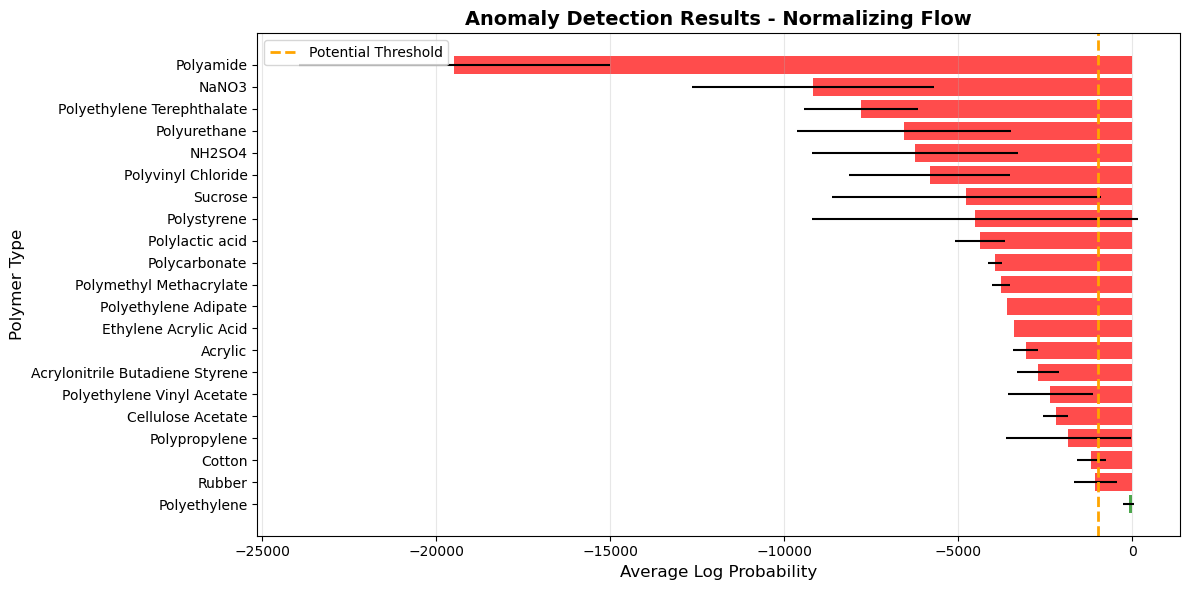

/var/folders/lz/0_wcbhjj0tdcm9t69tycht_c0000gn/T/ipykernel_32066/2767686227.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_for_box, labels=polymers_sorted, patch_artist=True, vert=True)


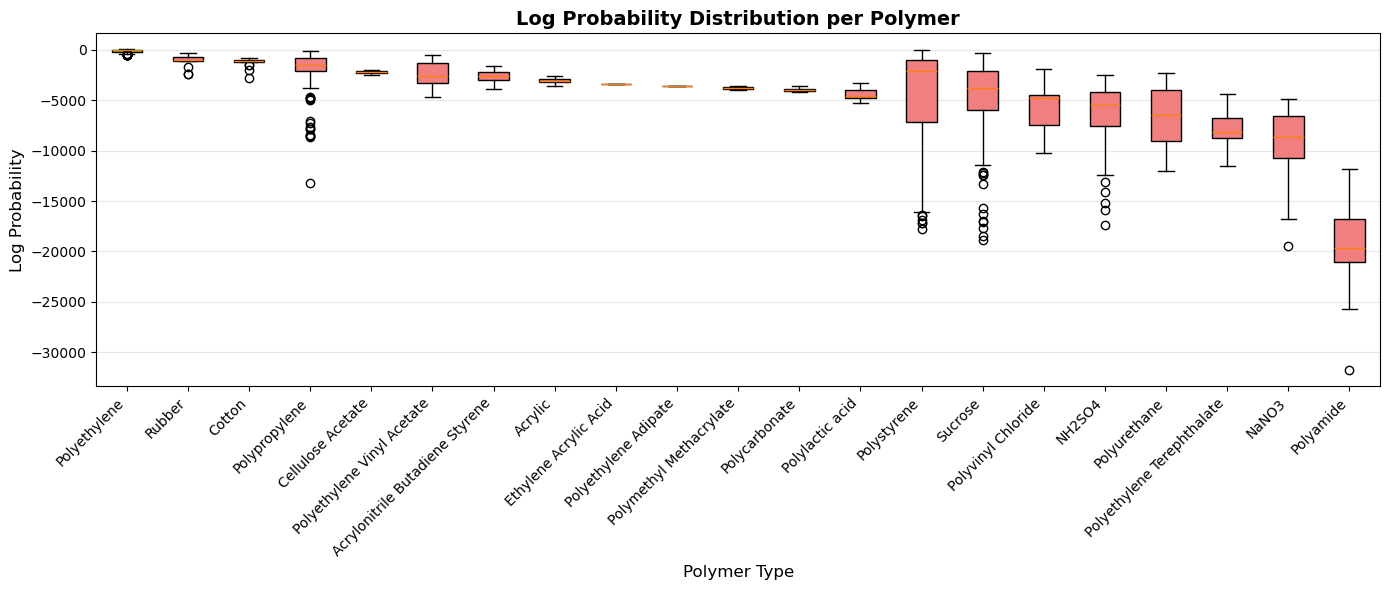

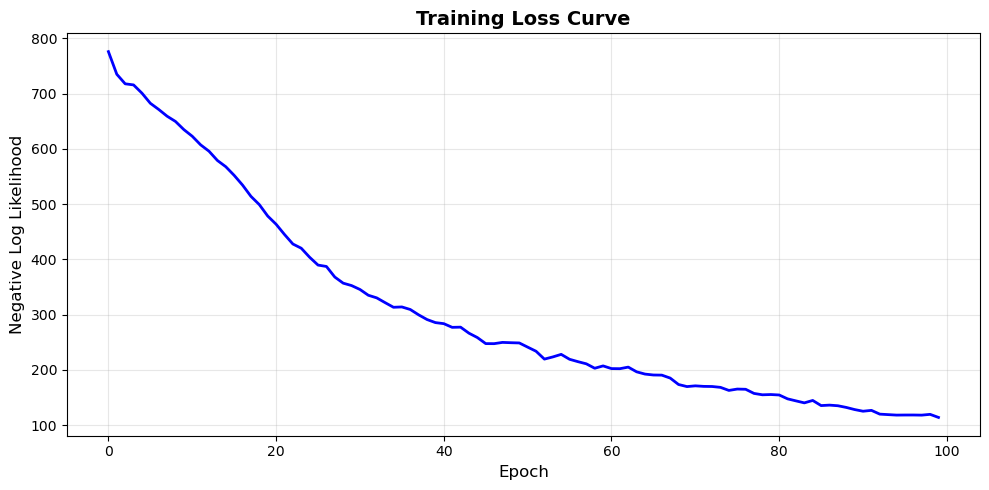


Polymer                                    Mean Log Prob        Std  N Samples
Polyethylene                                     -106.60     149.69        297 ← NORMAL
Rubber                                          -1067.19     615.71         16
Cotton                                          -1178.50     416.23         26
Polypropylene                                   -1836.91    1792.48        213
Cellulose Acetate                               -2201.60     353.75          2
Polyethylene Vinyl Acetate                      -2362.08    1220.71         15
Acrylonitrile Butadiene Styrene                 -2701.44     604.91         15
Acrylic                                         -3066.54     359.27          6
Ethylene Acrylic Acid                           -3388.82        nan          1
Polyethylene Adipate                            -3615.71        nan          1
Polymethyl Methacrylate                         -3765.62     255.46          2
Polycarbonate                             

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Collect results
model.eval()
results = {}
with torch.no_grad():
    for polymer in df['polymer'].unique():
        polymer_data = df[df['polymer'] == polymer].drop('polymer', axis=1).values
        polymer_scaled = scaler.transform(polymer_data)
        polymer_tensor = torch.FloatTensor(polymer_scaled)
        
        log_probs = model(polymer_tensor)
        results[polymer] = {
            'mean': log_probs.mean().item(),
            'std': log_probs.std().item(),
            'all_probs': log_probs.numpy()
        }

# 1. Bar plot of average log probabilities
polymers = list(results.keys())
means = [results[p]['mean'] for p in polymers]
stds = [results[p]['std'] for p in polymers]

# Sort by mean value
sorted_indices = np.argsort(means)[::-1]  # Descending order
polymers_sorted = [polymers[i] for i in sorted_indices]
means_sorted = [means[i] for i in sorted_indices]
stds_sorted = [stds[i] for i in sorted_indices]

plt.figure(figsize=(12, 6))
colors = ['green' if p == NORMAL_POLYMER else 'red' for p in polymers_sorted]
bars = plt.barh(polymers_sorted, means_sorted, xerr=stds_sorted, color=colors, alpha=0.7)
plt.xlabel('Average Log Probability', fontsize=12)
plt.ylabel('Polymer Type', fontsize=12)
plt.title('Anomaly Detection Results - Normalizing Flow', fontsize=14, fontweight='bold')
plt.axvline(x=-1000, color='orange', linestyle='--', linewidth=2, label='Potential Threshold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Distribution plot (box plot)
plt.figure(figsize=(14, 6))
data_for_box = [results[p]['all_probs'] for p in polymers_sorted]
bp = plt.boxplot(data_for_box, labels=polymers_sorted, patch_artist=True, vert=True)

# Color boxes
for patch, polymer in zip(bp['boxes'], polymers_sorted):
    if polymer == NORMAL_POLYMER:
        patch.set_facecolor('lightgreen')
    else:
        patch.set_facecolor('lightcoral')

plt.ylabel('Log Probability', fontsize=12)
plt.xlabel('Polymer Type', fontsize=12)
plt.title('Log Probability Distribution per Polymer', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Training loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Negative Log Likelihood', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Summary statistics table
print("\n" + "="*80)
print(f"{'Polymer':<40} {'Mean Log Prob':>15} {'Std':>10} {'N Samples':>10}")
print("="*80)
for polymer in polymers_sorted:
    mean_val = results[polymer]['mean']
    std_val = results[polymer]['std']
    n_samples = len(results[polymer]['all_probs'])
    marker = " ← NORMAL" if polymer == NORMAL_POLYMER else ""
    print(f"{polymer:<40} {mean_val:>15.2f} {std_val:>10.2f} {n_samples:>10}{marker}")
print("="*80)